# 05 — Model comparison: is ALS actually worth it?

Ferrari Dacrema et al., [*Are We Really Making Much Progress?*](https://arxiv.org/abs/1907.06902) (RecSys 2019), showed that fancy recommenders are routinely beaten by well-chosen **simple baselines**, and — just as important — that reported gains often aren't **significance-tested**. So this notebook does three things properly:

1. Compare the chosen ALS against strong baselines (popularity, item-item BM25, BPR) on the same frozen split, with accuracy *and* beyond-accuracy metrics.
2. **Significance-test** the differences with a paired user-level bootstrap — is ALS's lead real, or within noise?
3. Look at *who* each model wins for, not just the average.

If a result survives all three, it's credible.

In [1]:
import sys, warnings
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
warnings.filterwarnings('ignore', message='.*expects CSR input.*')  # implicit's COO->CSR notice

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from src import models, stats, plotting as viz
from src.harness import eval_core
from src.utils import TRAIN_PATH, TEST_PATH

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
K = 10
train = sp.load_npz(TRAIN_PATH); test = sp.load_npz(TEST_PATH).tocsr()
scored = np.where(np.asarray((test > 0).sum(axis=1)).ravel() > 0)[0]

## 1. The comparison table

Accuracy (NDCG, MAP, recall) and beyond-accuracy (coverage, novelty, Gini) over 3 seeds. Beyond-accuracy matters because a recommender can be accurate yet narrow.

In [2]:
df = pd.DataFrame(models.compare(train, test, k=K, seeds=(0, 1, 2)))
show = df[['model', f'ndcg@{K}', f'map@{K}', f'recall@{K}', 'coverage', 'novelty', 'gini']].round(4)
show.columns = ['model', 'NDCG@10', 'MAP@10', 'Recall@10', 'coverage', 'novelty(bits)', 'Gini']
show

,model,NDCG@10,MAP@10,Recall@10,coverage,novelty(bits),Gini
0,popularity,0.0630,0.0269,0.0631,0.0014,2.7529,0.9993
1,item-item BM25,0.1437,0.0681,0.1361,0.0286,3.4630,0.9966
2,BPR,0.1186,0.0539,0.1124,0.0486,5.3948,0.9797
3,ALS log1p (chosen),0.1710,0.0810,0.1672,0.0379,4.4531,0.9864


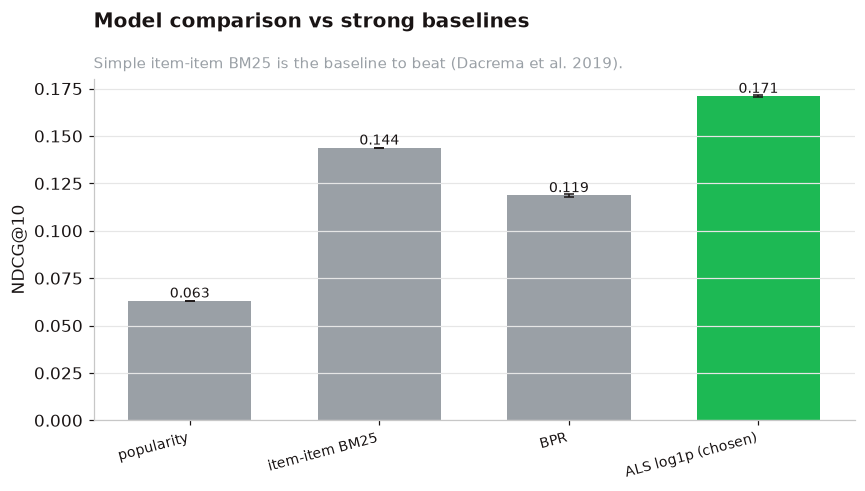

In [3]:
_ = viz.plot_model_comparison(df['model'].tolist(), df[f'ndcg@{K}'].tolist(),
                              df[f'ndcg@{K}_std'].tolist(), highlight='ALS log1p (chosen)',
                              save_path=FIG / 'model_comparison.png')

Popularity is weak, but the **item-item BM25 neighbourhood model is the real baseline** — simple, no factor model — and it's competitive. BPR (pairwise MF) underperforms it here. ALS leads, but by how much, and is it real?

## 2. Significance: paired user-level bootstrap

We score every model on the *same* users, take each user's NDCG@10, and bootstrap the **paired difference** (ALS minus baseline) by resampling users. A 95% CI that excludes 0 means a real difference, not split noise.

In [4]:
# per-user NDCG@10 for each model (seed 0)
per_user = {name: eval_core.per_user_scores(fn(train, scored, K, 0), test, scored, K)[f'ndcg@{K}']
            for name, fn in models.MODELS.items()}
als = per_user['ALS log1p (chosen)']
rows = []
for name in ['item-item BM25', 'BPR', 'popularity']:
    d = stats.paired_bootstrap_diff(als, per_user[name], seed=0)
    rows.append({'vs baseline': name, 'NDCG@10 diff': round(d['mean_diff'], 4),
                 'CI low': round(d['lo'], 4), 'CI high': round(d['hi'], 4),
                 'p (2-sided)': d['p_two_sided'], 'significant': d['significant'],
                 'users ALS wins': f"{(als > per_user[name]).mean()*100:.0f}%"})
pd.DataFrame(rows)

,vs baseline,NDCG@10 diff,CI low,CI high,p (2-sided),significant,users ALS wins
0,item-item BM25,0.0274,0.0214,0.0335,0.0,True,46%
1,BPR,0.0512,0.0454,0.0570,0.0,True,53%
2,popularity,0.1081,0.1011,0.1152,0.0,True,63%


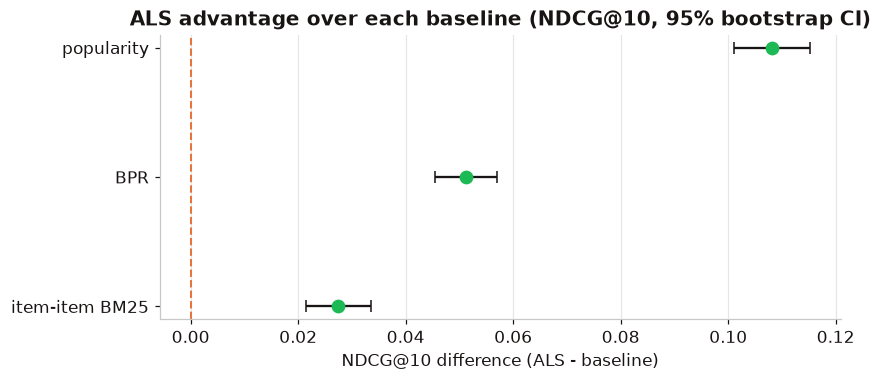

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(rows))
means = [r['NDCG@10 diff'] for r in rows]
lo = [r['NDCG@10 diff'] - r['CI low'] for r in rows]
hi = [r['CI high'] - r['NDCG@10 diff'] for r in rows]
ax.errorbar(means, y, xerr=[lo, hi], fmt='o', color=viz.GREEN, ecolor=viz.DARK, capsize=4, lw=1.5, ms=8)
ax.axvline(0, color=viz.ACCENT, ls='--', lw=1.3)
ax.set_yticks(y); ax.set_yticklabels([r['vs baseline'] for r in rows])
ax.set(title='ALS advantage over each baseline (NDCG@10, 95% bootstrap CI)',
       xlabel='NDCG@10 difference (ALS - baseline)')
ax.grid(axis='y', visible=False)
fig.tight_layout(); fig.savefig(FIG / 'model_significance.png'); plt.show()

**Every CI is comfortably above zero** — ALS's lead over even the strong BM25 baseline is statistically significant (p < 0.001), not an artefact of the split. This is the test Dacrema et al. argue is too often skipped; here the chosen model passes it. But note the *per-user* view ('users ALS wins'): ALS does not win for every user, only on average.

## 3. Where the models differ: the per-user distribution

The average hides structure. Plot the per-user NDCG@10 difference (ALS minus BM25).

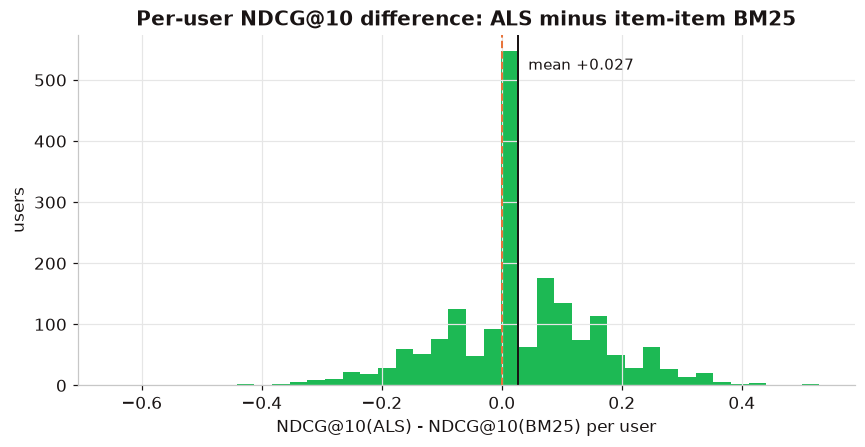

ALS strictly better for 46% of users, worse for 30%, tied for 24%.


In [6]:
diff = als - per_user['item-item BM25']
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(diff, bins=40, color=viz.GREEN)
ax.axvline(0, color=viz.ACCENT, ls='--', lw=1.3)
ax.axvline(diff.mean(), color=viz.DARK, ls='-', lw=1.3)
ax.text(diff.mean(), ax.get_ylim()[1]*0.9, f'  mean +{diff.mean():.3f}', color=viz.DARK, fontsize=10)
ax.set(title='Per-user NDCG@10 difference: ALS minus item-item BM25',
       xlabel='NDCG@10(ALS) - NDCG@10(BM25) per user', ylabel='users')
fig.tight_layout(); fig.savefig(FIG / 'per_user_diff.png'); plt.show()
print(f'ALS strictly better for {(diff>0).mean()*100:.0f}% of users, '
      f'worse for {(diff<0).mean()*100:.0f}%, tied for {(diff==0).mean()*100:.0f}%.')

Much of the mass is a tie (both models miss, or both hit similarly) — a reminder that at this sparsity many users are hard for *any* model. The net positive mean is driven by a meaningful minority where ALS's factor model captures structure BM25's co-occurrence counts miss. For a production system this argues for **routing** (use the cheaper BM25 where it ties ALS) more than a blanket choice.

## 4. The accuracy / novelty frontier

No model dominates on every axis: more novel recommendations tend to cost accuracy.

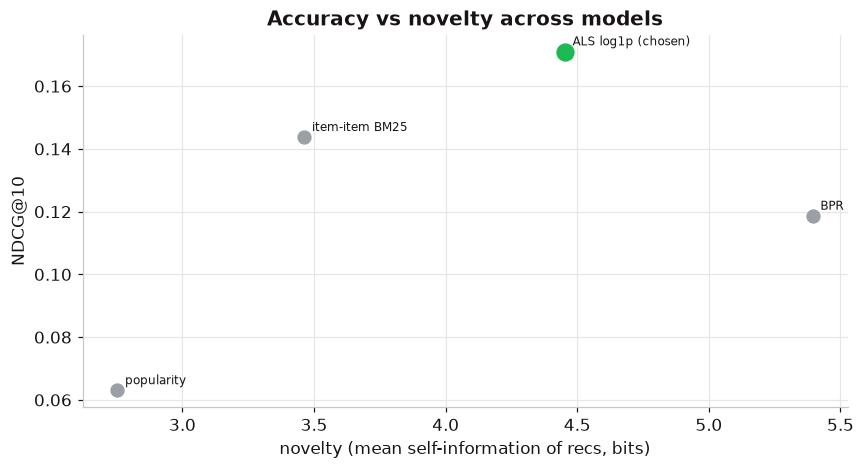

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for _, r in df.iterrows():
    chosen = r['model'] == 'ALS log1p (chosen)'
    ax.scatter(r['novelty'], r[f'ndcg@{K}'], s=120 if chosen else 70,
               color=viz.GREEN if chosen else viz.MUTED, zorder=3)
    ax.annotate(r['model'], (r['novelty'], r[f'ndcg@{K}']), fontsize=8, xytext=(5, 4), textcoords='offset points')
ax.set(title='Accuracy vs novelty across models',
       xlabel='novelty (mean self-information of recs, bits)', ylabel=f'NDCG@{K}')
fig.tight_layout(); fig.savefig(FIG / 'model_accuracy_novelty.png'); plt.show()

BPR recommends more novel (rarer) artists than ALS at lower accuracy; popularity is both inaccurate and un-novel. ALS sits at the accuracy frontier; BPR would be the pick if discovery were weighted more heavily — the same accuracy-vs-discovery lever the model card flags (and the API's `diversity` parameter exposes).

## Summary

- Against strong baselines (not just popularity), ALS is best on accuracy, and the lead over item-item BM25 is **statistically significant** (paired bootstrap, p < 0.001) — the result survives the test Dacrema et al. demand.
- The win is **not uniform across users**: many users are a tie at this sparsity; ALS pulls ahead on a meaningful minority. That nuance matters for routing/ensembling decisions.
- The models occupy different points on the accuracy/novelty frontier — choosing among them is a product question, surfaced honestly rather than averaged away.